# Klein et al. (2017) – Droplet Barcoding for Single-Cell Transcriptomics Applied to Embryonic Stem Cells

The original paper can be found here: https://www.sciencedirect.com/science/article/pii/S0092867415005000

__Abstract__: It has long been the dream of biologists to map gene expression at the single-cell level. With such data one might track heterogeneous cell sub-populations, and infer regulatory relationships between genes and pathways. Recently, RNA sequencing has achieved single-cell resolution. What is limiting is an effective way to routinely isolate and process large numbers of individual cells for quantitative in-depth sequencing. We have developed a high-throughput droplet-microfluidic approach for barcoding the RNA from thousands of individual cells for subsequent analysis by next-generation sequencing. The method shows a surprisingly low noise profile and is readily adaptable to other sequencing-based assays. We analyzed mouse embryonic stem cells, revealing in detail the population structure and the heterogeneous onset of differentiation after leukemia inhibitory factor (LIF) withdrawal. The reproducibility of these high-throughput single-cell data allowed us to deconstruct cell populations and infer gene expression relationships.

Klein et al. analyze 2,717 single cells. The 4 classes in which they mention aren’t cell types but rather experimental conditions/timepoints:

What the 4 classes are
- 0 days (baseline mESCs, +LIF)
- 2 days after LIF withdrawal
- 4 days after LIF withdrawal
- 7 days after LIF withdrawal

Klein profiled mESCs before and after LIF withdrawal to study early differentiation dynamics; GEO lists data for baseline ES cells and LIF− at days 2, 4, 7, which are the four-condition split many benchmarks (incl. scMINER) use.

## 0. Imports & Set-Up:

In [1]:
# add Leiden!

from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances, adjusted_rand_score
from sklearn.preprocessing import FunctionTransformer

import umap
from umap import UMAP

import numpy as np
import pandas as pd

import scanpy as sc
import anndata as ad, io, gzip, os

import matplotlib.pyplot as plt

from carve import CARVE
from carve.config import ValidatorConfig

from pathlib import Path

In [2]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Pre-Process the Data

In [3]:
DATA_DIR = Path("../data/klein")  # change if needed
files = {
    "d0": DATA_DIR / "GSM1599494_ES_d0_main.csv.bz2",
    "d2": DATA_DIR / "GSM1599497_ES_d2_LIFminus.csv.bz2",
    "d4": DATA_DIR / "GSM1599498_ES_d4_LIFminus.csv.bz2",
    "d7": DATA_DIR / "GSM1599499_ES_d7_LIFminus.csv.bz2",
}

def read_block(path):
    df = pd.read_csv(path, header=None, index_col=0, compression="bz2")
    
    # ensure numeric (coerce odd strings to NaN and fill to 0)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    
    # deduplicate any gene ids just in case
    df = df[~df.index.duplicated(keep="first")]
    
    return df  # genes × cells

read four matrices (genes × cells):

In [4]:
d0 = read_block(files["d0"])
d2 = read_block(files["d2"])
d4 = read_block(files["d4"])
d7 = read_block(files["d7"])

outer-join on genes, concat columns:

In [5]:
genes = d0.index.union(d2.index).union(d4.index).union(d7.index)
d0 = d0.reindex(genes).fillna(0.0)
d2 = d2.reindex(genes).fillna(0.0)
d4 = d4.reindex(genes).fillna(0.0)
d7 = d7.reindex(genes).fillna(0.0)

expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)  # genes × cells
print("genes × cells:", expr_gxc.shape)

genes × cells: (24175, 2717)


make unique cell ids & 4-class labels:

In [6]:
def add_prefix(df, pref):
    df.columns = [f"{pref}_{i+1:04d}" for i in range(df.shape[1])]
    return df

d0 = add_prefix(d0, "d0"); d2 = add_prefix(d2, "d2")
d4 = add_prefix(d4, "d4"); d7 = add_prefix(d7, "d7")
expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)

labels = (
    ["d0"] * d0.shape[1] +
    ["d2"] * d2.shape[1] +
    ["d4"] * d4.shape[1] +
    ["d7"] * d7.shape[1]
)

cells = expr_gxc.columns
y = pd.Series(labels, index=cells, name="condition").astype("category")

build AnnData (cells × genes), keep raw counts in .layers["counts"]

In [7]:
adata = ad.AnnData(
    X=expr_gxc.T.values.astype(np.float32),  # cells × genes
    obs=pd.DataFrame(index=cells),
    var=pd.DataFrame(index=expr_gxc.index.astype(str)),
)

adata.obs["condition"] = y
adata.layers["counts"] = adata.X.copy()  # raw UMIs; no log yet

print(adata)
print(adata.obs["condition"].value_counts())

AnnData object with n_obs × n_vars = 2717 × 24175
    obs: 'condition'
    layers: 'counts'
condition
d0    933
d7    798
d4    683
d2    303
Name: count, dtype: int64


write for reuse:

In [8]:
# adata.write("klein_d0_d2_d4_d7_raw.h5ad")

---

## 2. Analyse Data

In [9]:
print(f"np.unique(obs): {np.unique(adata.obs['condition'].values)}")
print(f"len(np.unique(obs)): {len(np.unique(np.unique(adata.obs['condition'].values)))}")

np.unique(obs): ['d0' 'd2' 'd4' 'd7']
len(np.unique(obs)): 4


In [10]:
# extract X (cells × genes) from AnnData into a pandas DataFrame
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
print("X.shape:", X.shape)

X.shape: (2717, 24175)


PCA plot of raw gene counts:

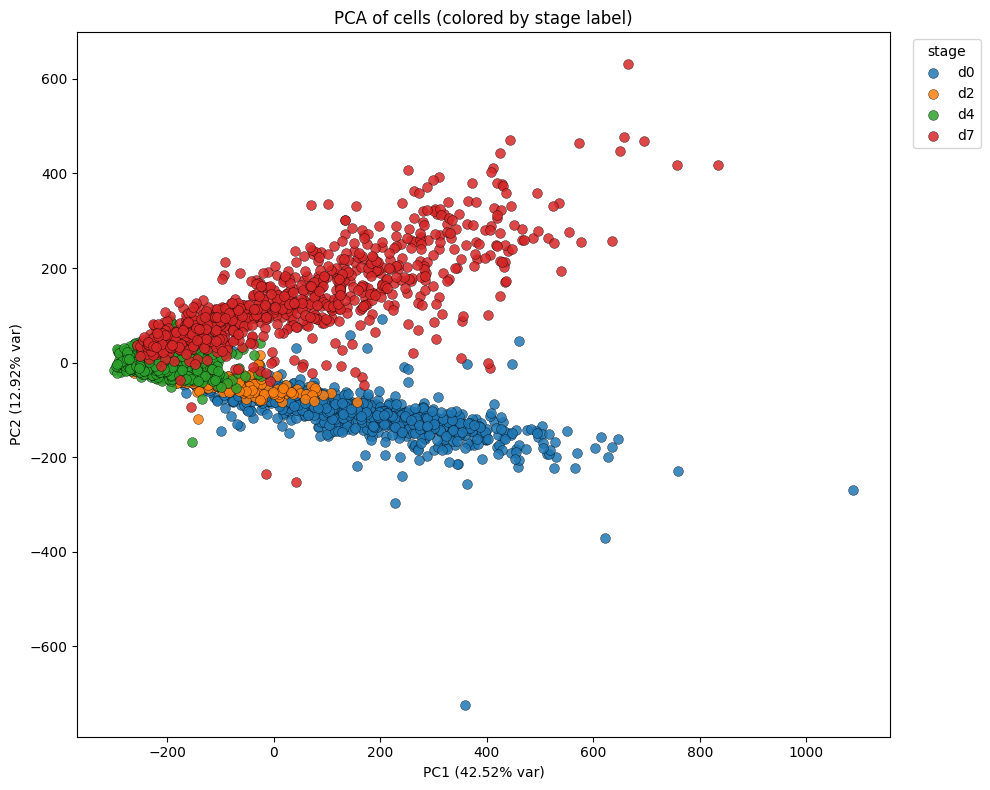

In [11]:
# PCA on cells (samples are columns of X) and scatter plot colored by y
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)  # shape: (n_cells, 2)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Normalize and Select Highly-Variable Genes:

In [12]:
print(adata.obs.columns)

Index(['condition'], dtype='object')


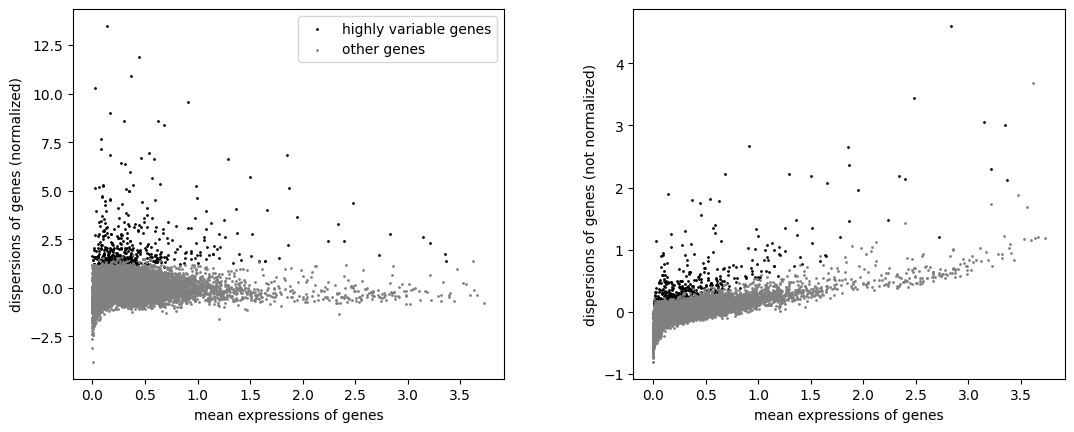

In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="condition", flavor='seurat')
sc.pl.highly_variable_genes(adata)

Subset to HVGs only:

In [14]:
adata = adata[:, adata.var["highly_variable"]].copy()

In [15]:
# # Overwrite X and y using the (HVG-subset) adata
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (2717, 500)
y.shape: (2717,)


PCA of log1p transformed 500 HVGs:

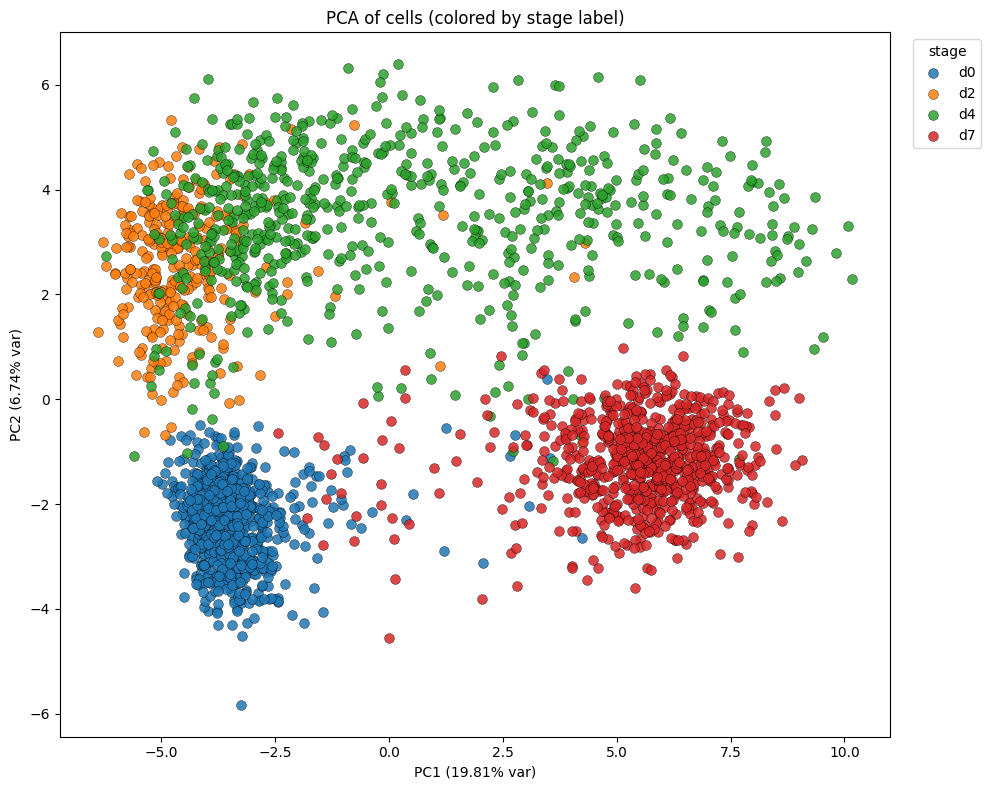

In [16]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
pc_df['label'] = y

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of cells (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

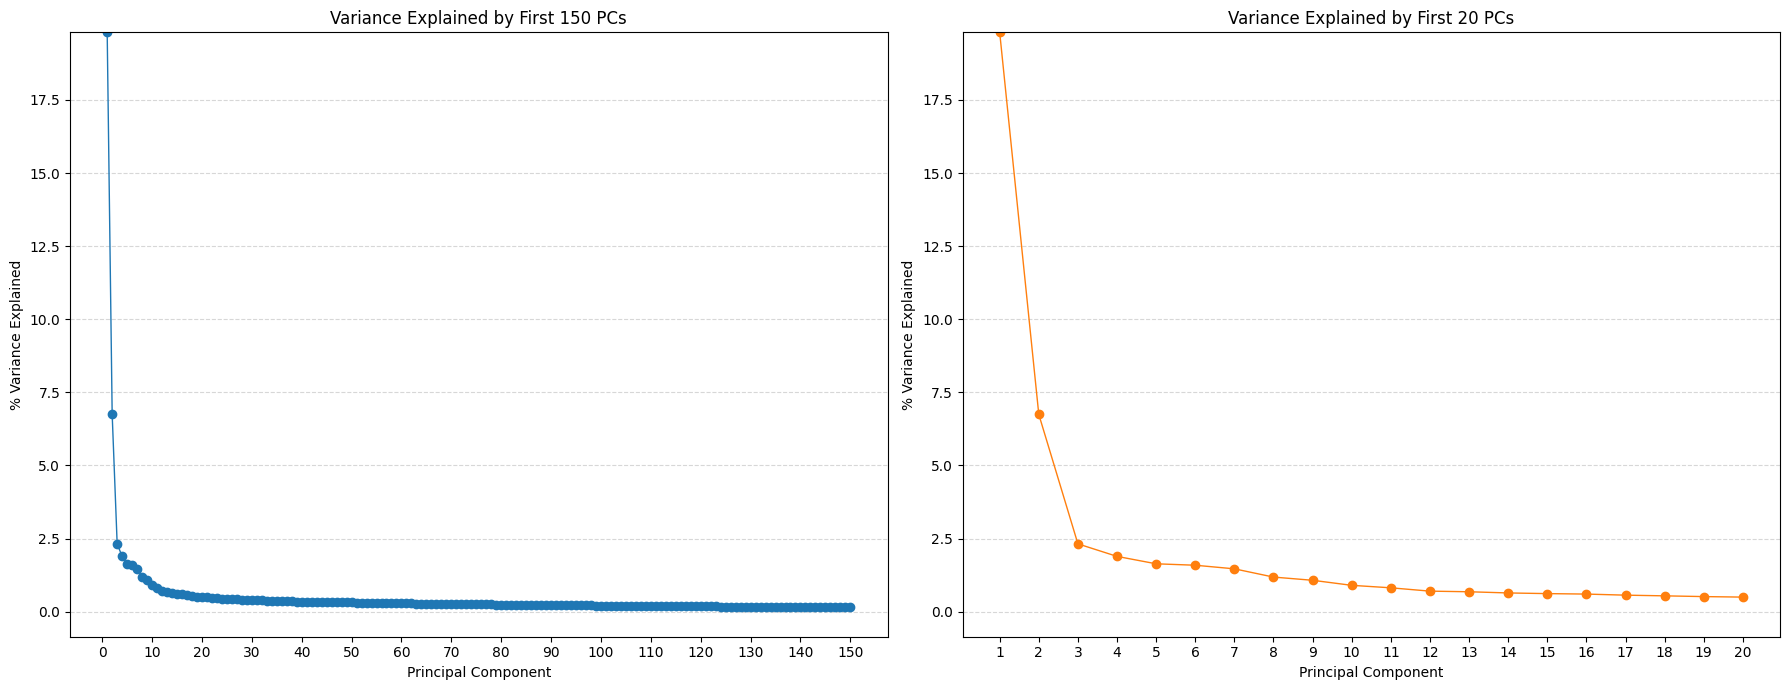

In [17]:
pca = PCA(n_components=150)
pcs = pca.fit_transform(X)

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
ymin = min(pca.explained_variance_ratio_[:150] * 100).min() - 1
ymax = max(pca.explained_variance_ratio_[:150] * 100).max()
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

ax[0].plot(np.arange(1, 151), pca.explained_variance_ratio_[:150] * 100, marker='o', linewidth=1)
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('% Variance Explained')
ax[0].set_title('Variance Explained by First 150 PCs')
ax[0].set_xticks(np.arange(0, 151, 10))
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

ax[1].plot(np.arange(1, 21), pca.explained_variance_ratio_[:20] * 100, marker='o', linewidth=1, color='tab:orange')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('% Variance Explained')
ax[1].set_title('Variance Explained by First 20 PCs')
ax[1].set_xticks(np.arange(1, 21, 1))
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Find largest drop in explained variance ratio between PCs ~6 and 20:

In [18]:
start = 6
end = 20

expl_var = pca.explained_variance_ratio_[:20] * 100
diffs = np.diff(expl_var)

drop_start = start - 1  # PC12 is index 11
drop_end = end - 1  # PC20 is index 19
drop_idx = np.argmin(diffs[drop_start:drop_end]) + drop_start

print(f"Largest drop between PC{start} and PC{end} is between PC{drop_idx+1} and PC{drop_idx+2}:")
print(f"Explained variance drops from {expl_var[drop_idx]:.2f}% to {expl_var[drop_idx+1]:.2f}% (Δ = {diffs[drop_idx]:.2f}%)")

Largest drop between PC6 and PC20 is between PC7 and PC8:
Explained variance drops from 1.46% to 1.18% (Δ = -0.28%)


In [19]:
cutoff = 7

explained_var = pca.explained_variance_ratio_[:cutoff].sum() * 100
print(f"Cumulative variance explained by the first {cutoff} PCs: {explained_var:.2f}%")

Cumulative variance explained by the first 7 PCs: 35.45%


Only ~35% of explained variance may be insufficient. Let us also consider how many PCs we would need to explain ~80% of variance:

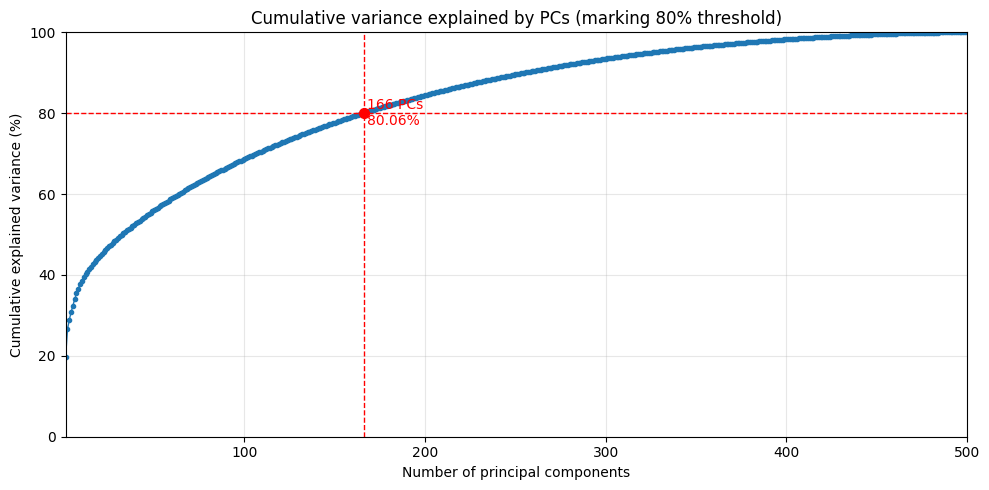

In [20]:
n_pcs_full = min(X.shape[0], X.shape[1])

pca_full = PCA(n_components=n_pcs_full)
pca_full.fit(X)
evr = pca_full.explained_variance_ratio_

cum_var = np.cumsum(evr)  # fraction (0..1)
n_needed = np.searchsorted(cum_var, 0.80) + 1  # PCs required to reach >=80%

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, len(evr) + 1)

ax.plot(x, cum_var * 100, marker='o', markersize=3, lw=1)
ax.axhline(80, color='red', linestyle='--', lw=1)
ax.axvline(n_needed, color='red', linestyle='--', lw=1)

ax.scatter([n_needed], [cum_var[n_needed - 1] * 100], color='red', s=50, zorder=5)
ax.text(
        n_needed + 2, 
        cum_var[n_needed - 1] * 100,
        f"{n_needed} PCs\n{cum_var[n_needed - 1]*100:.2f}%", color='red', va='center'
)

ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("Cumulative variance explained by PCs (marking 80% threshold)")
ax.set_xlim(1, min(len(evr), 500))
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

### Determine Pre-Processing Pipeline with CARVE:

In [21]:
norm_options = [
    (FunctionTransformer, {}), 
]

dr_options = [
    (PCA, 'pca_7',{
        'n_components': [7]
    }),
    (PCA, 'pca_166',{
        'n_components': [166]
    }),
    (TSNE, 'tsne5',{
        'n_components': [2], 
        'perplexity': [5]
    }),
    (TSNE, 'tsne15',{
        'n_components': [2], 
        'perplexity': [15]
    }),
    (TSNE, 'tsne30',{
        'n_components': [2], 
        'perplexity': [30]
    }),
    (UMAP, 'umap_5',{
        'n_components': [2], 
        'n_neighbors': [5], 
        'min_dist': [0.1]
    }),
    (UMAP, 'umap_10',{
        'n_components': [2], 
        'n_neighbors': [10], 
        'min_dist': [0.1]
    }),
    (UMAP, {
        'n_components': [2], 
        'n_neighbors': [15], 
        'min_dist': [0.1]
    }),
]

cfg = ValidatorConfig(
    X=X,
    K=10,
    B=100,
    norm_options=norm_options,
    dr_options=dr_options,
    ref_labels=y
)

val = CARVE(cfg)
val.validate(random_preprocess=True, random_state=42)

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

KeyboardInterrupt: 

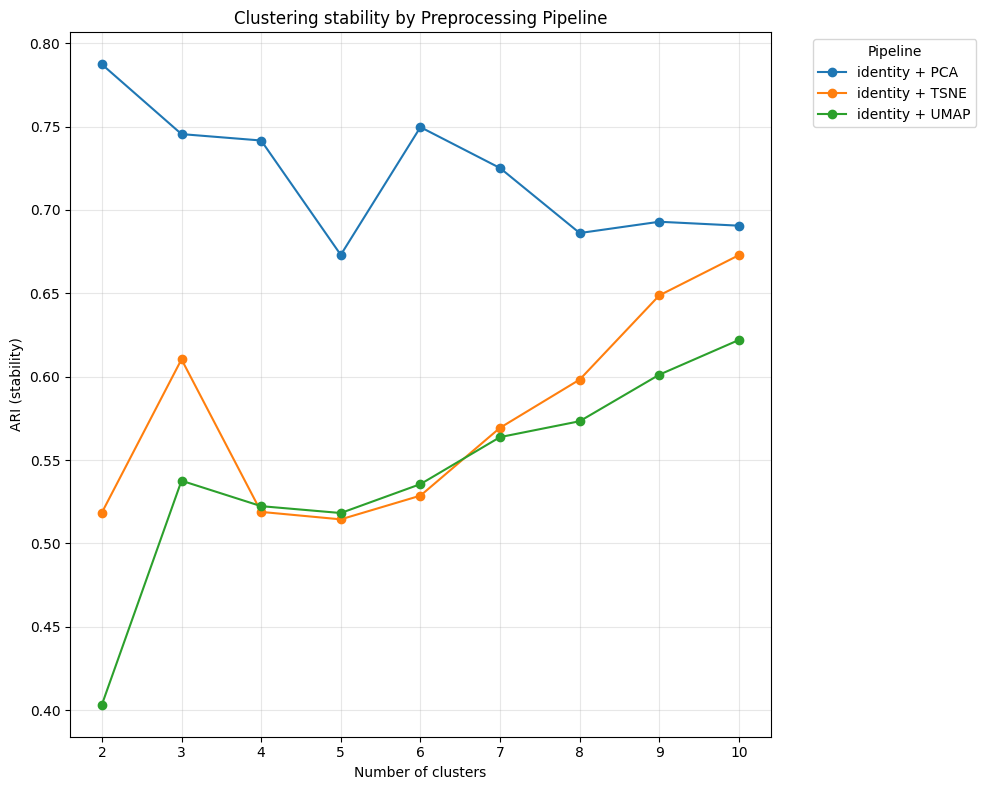

In [57]:
val.plot_preprocessing_results()

---
### Determine Optimal Clustering with CARVE:

In [59]:
pca = PCA(n_components=15)
X_log_pca = pca.fit_transform(X)
print("X_log_pca shape:", X_log_pca.shape)

X_log_pca shape: (527, 15)


In [61]:
cfg = ValidatorConfig(
    X=X_log_pca,
    K=10,
    B=100,
    ref_labels=y
)

val = CARVE(cfg)
val.validate(random_preprocess=False, random_state=42)

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

In [62]:
val.plot_results(measure='s', rule='1se')

In [63]:
val.plot_results(measure='g', rule='1se')

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/_plotting.py:474: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



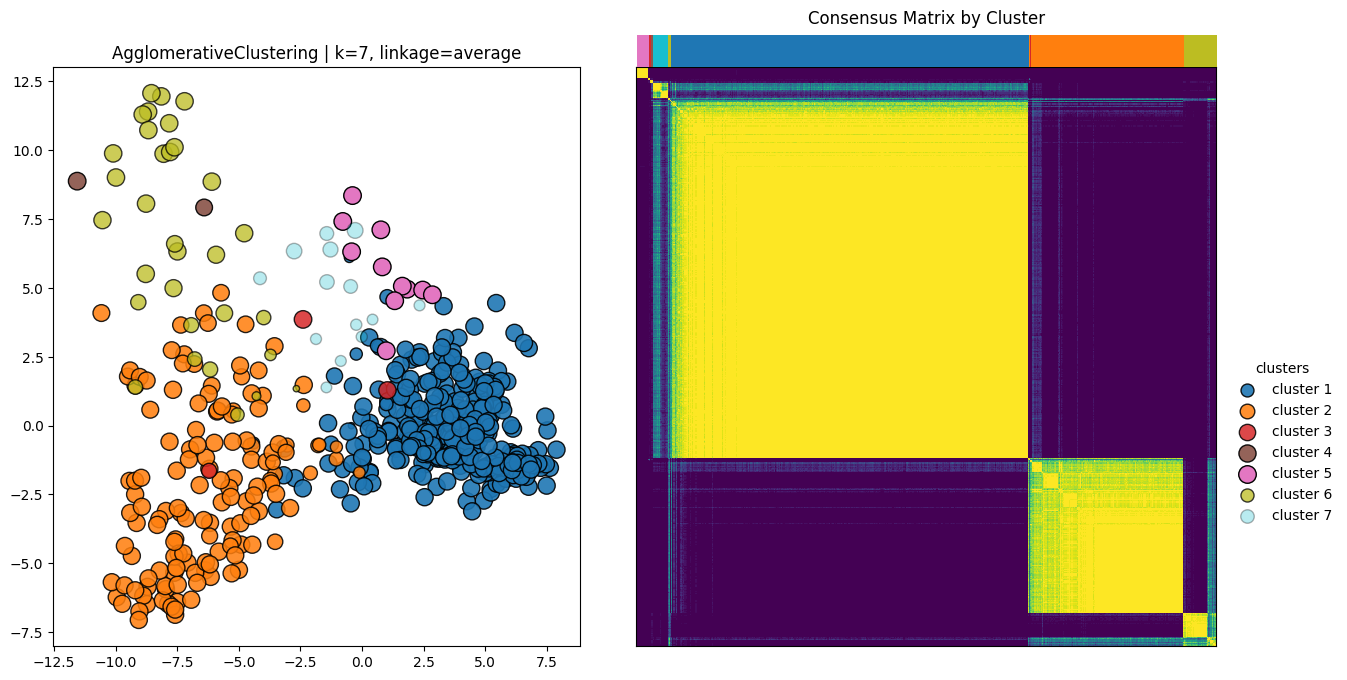

In [68]:
val.plot_consensus_clustering(k=7, figsize=(15, 8))

In [69]:
val.plot_clustering(k=7, measure='s', rule='1se')

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAAGEAAAAAAAAAAAAAAAAAAAP' ... 'CMamPS7j8AvD45uQLuPwAAAAAAAAAA'),
                             'dtype': 'f8',
                             'shape': '3, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.8463997761957549,
                         'size': {'bdata': 'yJKGGVjOKkBcaih10OgmQB9vY2pQUypA', 'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': '38909a44-3654-4619-b1e7-ad104a125017',
              'x': {'bdata': 'hTUZwCGTxsCV+oM/', 'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': '5M12QM8Q0r+58qM/', 'dtype': 'f4'},
              'yaxi

In [70]:
agg = AgglomerativeClustering(n_clusters=7, linkage='average')
pred_labels = agg.fit_predict(X_log_pca)
ari = adjusted_rand_score(y, pred_labels)
print(f"ARI of AgglomerativeClustering (ward linkage) with true labels: {ari:.4f}")

ARI of AgglomerativeClustering (ward linkage) with true labels: 0.7426
